<a href="https://colab.research.google.com/github/islombek-cs/Computer-Vision-Labs/blob/main/CV_LAB_10_(cont_)_CNN_based_VAE_and_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Islombek Abdurakhmanov  
**Student ID:** 221236  
**Shared Colab Link:** https://colab.research.google.com/drive/1F7yK6tpM4DtTN5dv-_TZhV7n65bxVIO9?usp=sharing

#CV_LAB 10 (cont.) - CNN based VAE and GAN

## Variational Autoencoder (VAE) on MNIST — PyTorch
- Trains a simple VAE (Encoder -> reparameterization -> Decoder)
- Logs loss curves
- Shows reconstructions & random samples
- Includes latent interpolation and 2D latent scatter (if z_dim=2)
- CUDA-optional, will use GPU if available

In [ ]:
import os, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils as vutils
import matplotlib.pyplot as plt

# -----------------------------
class Cfg:
    seed = 42
    batch_size = 128
    epochs = 10
    lr = 2e-3
    z_dim = 16
    img_size = 28
    log_interval = 100
    workdir = "./vae_artifacts"

cfg = Cfg()

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(cfg.seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(cfg.workdir, exist_ok=True)
print("Device:", device)

# -----------------------------
# Data
# -----------------------------
transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)

# -----------------------------
# Model
# -----------------------------
class Encoder(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64*7*7, z_dim)
        self.fc_logvar = nn.Linear(64*7*7, z_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)

class Decoder(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(z_dim, 64*7*7), nn.ReLU(True))
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 64, 7, 7)
        return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.enc = Encoder(z_dim)
        self.dec = Decoder(z_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar

def vae_loss(x, x_hat, mu, logvar):
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl, recon, kl

model = VAE(cfg.z_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

# -----------------------------
# Training/Eval
# -----------------------------
train_hist = {"loss":[], "recon":[], "kl":[]}
test_hist =  {"loss":[], "recon":[], "kl":[]}

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = total_recon = total_kl = 0

    for x, _ in loader:
        x = x.to(device)
        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x, x_hat, mu, logvar)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return total_loss/n, total_recon/n, total_kl/n

print("Training...")
for ep in range(1, cfg.epochs+1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader, train=False)
    train_hist["loss"].append(tr[0])
    test_hist["loss"].append(te[0])
    print(f"Epoch {ep:02d} | train loss={tr[0]:.2f} | test loss={te[0]:.2f}")

# -----------------------------
# Reconstructions
# -----------------------------
model.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.to(device)
    x_hat, _, _ = model(x)

    grid = torch.cat([x[:8], x_hat[:8]], dim=0)
    vutils.save_image(grid, f"{cfg.workdir}/recon.png", nrow=8)
    print("Saved reconstructions.")

# -----------------------------
# Random Samples
# -----------------------------
with torch.no_grad():
    z = torch.randn(64, cfg.z_dim).to(device)
    x_hat = model.dec(z)
    vutils.save_image(x_hat, f"{cfg.workdir}/samples.png", nrow=8)
    print("Saved samples.")

print("Done.")


Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.76MB/s]


Training...
Epoch 01 | train loss=156.00 | test loss=115.17
Epoch 02 | train loss=112.35 | test loss=108.85
Epoch 03 | train loss=108.59 | test loss=107.17
Epoch 04 | train loss=106.75 | test loss=105.48
Epoch 05 | train loss=105.66 | test loss=104.49
Epoch 06 | train loss=104.74 | test loss=104.19
Epoch 07 | train loss=104.16 | test loss=103.51
Epoch 08 | train loss=103.62 | test loss=103.21
Epoch 09 | train loss=103.16 | test loss=103.66
Epoch 10 | train loss=102.80 | test loss=102.30
Saved reconstructions.
Saved samples.
Done.


## DCGAN on MNIST — PyTorch
- Trains a simple DCGAN (Generator vs Discriminator) at 28x28x1
- Uses non-saturating GAN loss (BCEWithLogits on D, standard G loss)
- Logs losses, saves sample grids every epoch, shows final plots
- CUDA-optional, will use GPU if available

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 409kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


Epoch 01 | step 100/469 | D 0.500 | G 1.997
Epoch 01 | step 200/469 | D 0.621 | G 2.104
Epoch 01 | step 300/469 | D 0.538 | G 1.546
Epoch 01 | step 400/469 | D 0.323 | G 1.853
[Epoch 01] D=0.593 | G=1.884


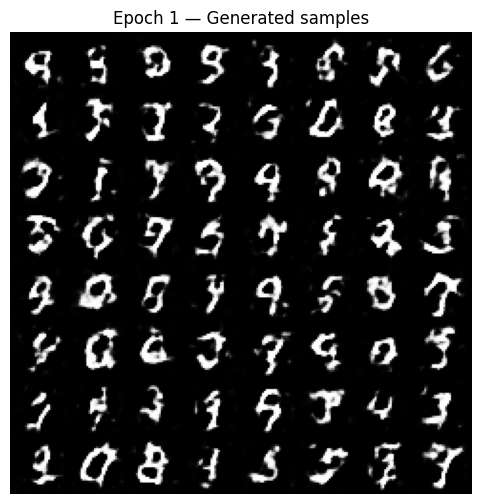

Epoch 02 | step 100/469 | D 0.414 | G 1.874
Epoch 02 | step 200/469 | D 0.557 | G 1.569
Epoch 02 | step 300/469 | D 0.503 | G 2.260
Epoch 02 | step 400/469 | D 0.761 | G 1.324
[Epoch 02] D=0.574 | G=2.025


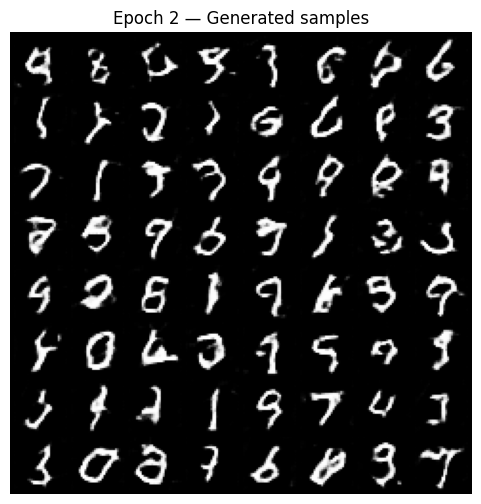

Epoch 03 | step 100/469 | D 0.549 | G 2.599
Epoch 03 | step 200/469 | D 0.717 | G 2.323
Epoch 03 | step 300/469 | D 0.689 | G 1.956
Epoch 03 | step 400/469 | D 0.659 | G 1.933
[Epoch 03] D=0.635 | G=1.862


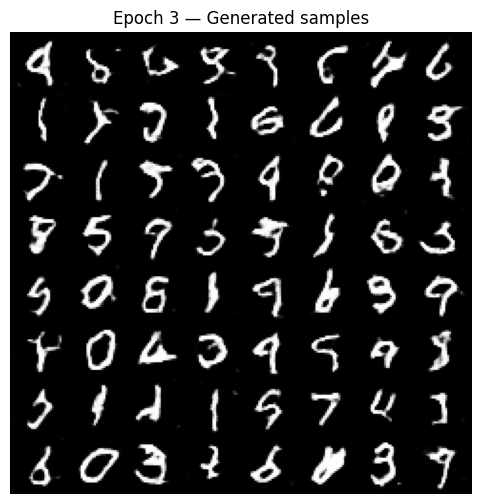

Epoch 04 | step 100/469 | D 0.556 | G 2.049
Epoch 04 | step 200/469 | D 0.564 | G 3.205
Epoch 04 | step 300/469 | D 0.421 | G 1.762
Epoch 04 | step 400/469 | D 0.522 | G 1.550
[Epoch 04] D=0.602 | G=1.932


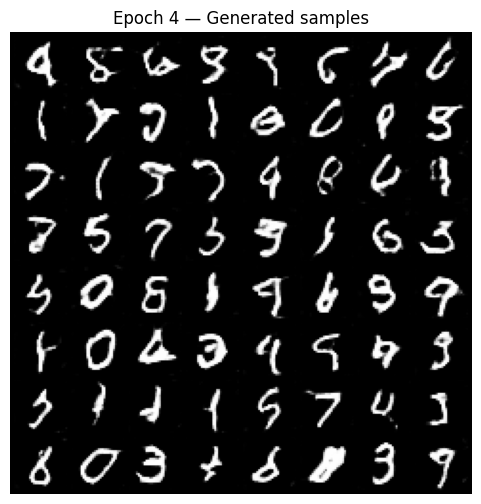

Epoch 05 | step 100/469 | D 0.478 | G 1.613
Epoch 05 | step 200/469 | D 0.574 | G 2.796
Epoch 05 | step 300/469 | D 0.511 | G 2.124
Epoch 05 | step 400/469 | D 0.457 | G 1.622
[Epoch 05] D=0.588 | G=1.981


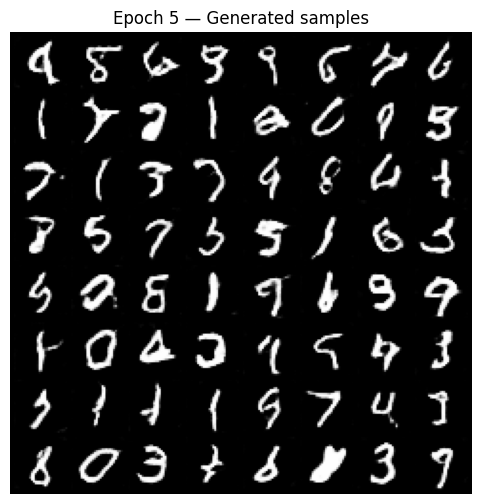

Epoch 06 | step 100/469 | D 0.527 | G 2.024
Epoch 06 | step 200/469 | D 0.428 | G 1.833
Epoch 06 | step 300/469 | D 0.510 | G 2.263
Epoch 06 | step 400/469 | D 0.470 | G 1.319
[Epoch 06] D=0.577 | G=1.958


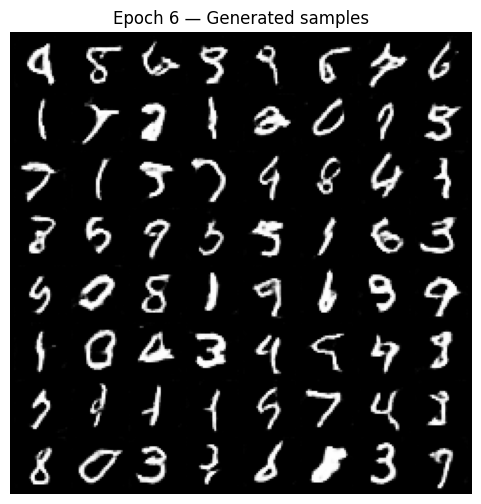

Epoch 07 | step 100/469 | D 0.373 | G 1.905
Epoch 07 | step 200/469 | D 0.607 | G 2.843
Epoch 07 | step 300/469 | D 0.561 | G 2.723
Epoch 07 | step 400/469 | D 0.523 | G 2.676
[Epoch 07] D=0.547 | G=2.043


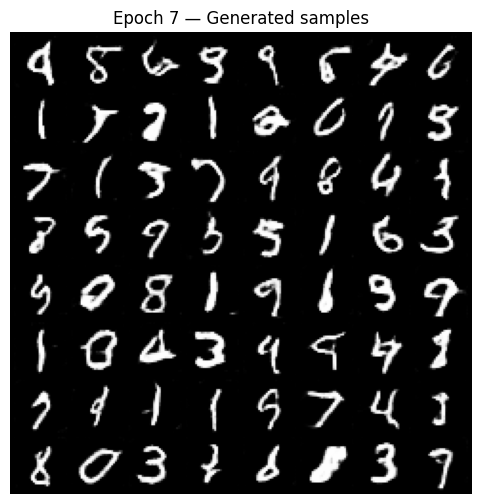

Epoch 08 | step 100/469 | D 0.452 | G 2.402
Epoch 08 | step 200/469 | D 0.506 | G 1.826
Epoch 08 | step 300/469 | D 0.447 | G 2.168
Epoch 08 | step 400/469 | D 0.553 | G 1.463
[Epoch 08] D=0.537 | G=2.092


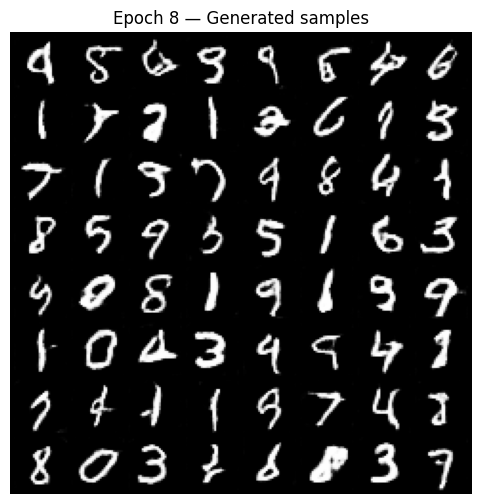

Epoch 09 | step 100/469 | D 0.422 | G 2.094
Epoch 09 | step 200/469 | D 0.368 | G 2.407
Epoch 09 | step 300/469 | D 0.296 | G 2.389
Epoch 09 | step 400/469 | D 0.397 | G 1.783
[Epoch 09] D=0.552 | G=2.070


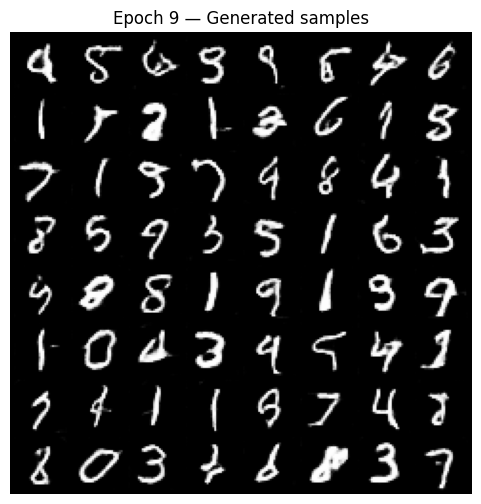

Epoch 10 | step 100/469 | D 0.496 | G 2.633
Epoch 10 | step 200/469 | D 0.645 | G 1.513
Epoch 10 | step 300/469 | D 0.358 | G 2.694
Epoch 10 | step 400/469 | D 0.468 | G 2.762
[Epoch 10] D=0.513 | G=2.119


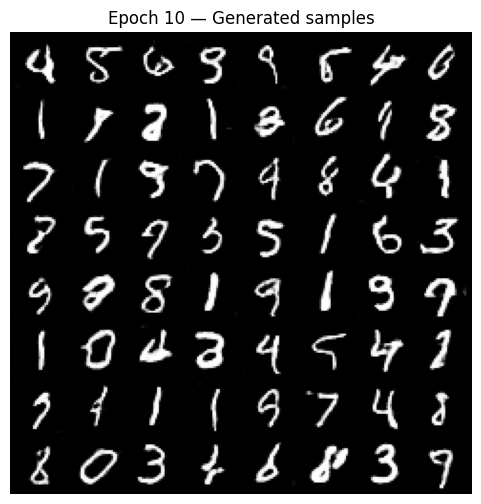

Done in 152.6s


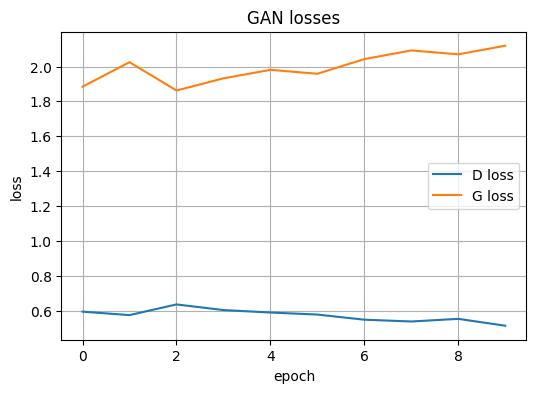

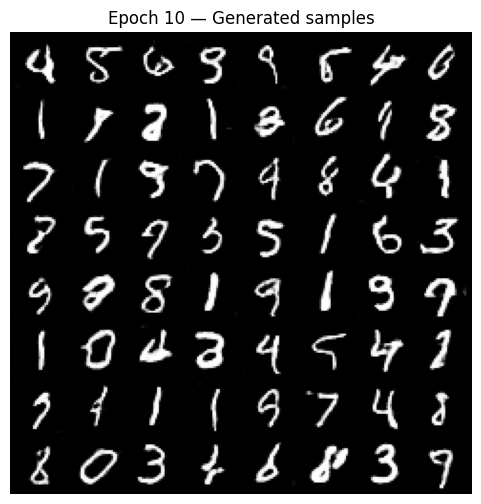

Artifacts saved to ./dcgan_mnist_artifacts


In [1]:
import os, math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils as vutils
import matplotlib.pyplot as plt

# -------------------------
# Config
# -------------------------
class Cfg:
    seed          = 42
    batch_size    = 128
    epochs        = 10        # bump to 25-50 for nicer results
    lr_g          = 2e-4
    lr_d          = 2e-4
    betas         = (0.5, 0.999)
    z_dim         = 100
    img_size      = 28
    workdir       = "./dcgan_mnist_artifacts"
    n_sample_grid = 64        # samples per grid
    log_interval  = 100

cfg = Cfg()

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(cfg.workdir, exist_ok=True)
print("Device:", device)

# -------------------------
# Data (normalize to [-1, 1] for Tanh)
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),                      # [0,1]
    transforms.Normalize((0.5,), (0.5,)),       # -> [-1,1]
])
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True)

# -------------------------
# Model: DCGAN-ish for 28x28x1
# -------------------------
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if getattr(m, "bias", None) is not None:
            nn.init.zeros_(m.bias.data)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.zeros_(m.bias.data)

class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        # Project to 7x7x128 then upsample to 14x14 -> 28x28
        self.fc = nn.Sequential(
            nn.Linear(z_dim, 128*7*7, bias=False),
            nn.BatchNorm1d(128*7*7),
            nn.ReLU(True)
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),  # 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1, bias=False),   # 28x28
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Conv2d(32, 1, 3, stride=1, padding=1),                         # 28x28x1
            nn.Tanh()
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 7, 7)
        x = self.deconv(h)
        return x

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # No sigmoid here; use BCEWithLogitsLoss
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),     # 14x14
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),    # 7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),   # 4x4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128*4*4, 1)
        )

    def forward(self, x):
        return self.net(x).view(-1)  # logits

G = Generator(cfg.z_dim).to(device)
D = Discriminator().to(device)
G.apply(weights_init); D.apply(weights_init)

opt_g = torch.optim.Adam(G.parameters(), lr=cfg.lr_g, betas=cfg.betas)
opt_d = torch.optim.Adam(D.parameters(), lr=cfg.lr_d, betas=cfg.betas)
bce = nn.BCEWithLogitsLoss()

fixed_noise = torch.randn(cfg.n_sample_grid, cfg.z_dim, device=device)

# -------------------------
# Training loop
# -------------------------
hist = {"g": [], "d": []}

def save_samples(epoch, noise=None, fname=None):
    G.eval()
    with torch.no_grad():
        z = noise if noise is not None else fixed_noise
        fake = G(z).cpu()  # in [-1,1]
        grid = vutils.make_grid(fake, nrow=8, normalize=True, value_range=(-1,1))
        plt.figure(figsize=(6,6))
        plt.axis("off"); plt.title(f"Epoch {epoch} — Generated samples")
        plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
        plt.show()
        if fname:
            vutils.save_image(fake, fname, nrow=8, normalize=True, value_range=(-1,1))
    G.train()

start = time.time()
global_step = 0
for ep in range(1, cfg.epochs+1):
    d_running = g_running = 0.0
    n_batches = 0

    for i, (real, _) in enumerate(train_loader):
        real = real.to(device, non_blocking=True)
        bs = real.size(0)
        n_batches += 1

        # -----------------
        # Train D: maximize log D(x) + log (1 - D(G(z)))
        # -----------------
        opt_d.zero_grad()
        z = torch.randn(bs, cfg.z_dim, device=device)
        fake = G(z).detach()
        real_logits = D(real)
        fake_logits = D(fake)

        real_targets = torch.ones(bs, device=device)
        fake_targets = torch.zeros(bs, device=device)

        d_loss_real = bce(real_logits, real_targets)
        d_loss_fake = bce(fake_logits, fake_targets)
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        opt_d.step()

        # -----------------
        # Train G: minimize -log D(G(z))  (non-saturating)
        # -----------------
        opt_g.zero_grad()
        z = torch.randn(bs, cfg.z_dim, device=device)
        fake = G(z)
        fake_logits = D(fake)
        g_loss = bce(fake_logits, real_targets)  # want D(fake)=1
        g_loss.backward()
        opt_g.step()

        d_running += d_loss.item()
        g_running += g_loss.item()
        global_step += 1

        if (i+1) % cfg.log_interval == 0:
            print(f"Epoch {ep:02d} | step {i+1}/{len(train_loader)} | "
                  f"D {d_loss.item():.3f} | G {g_loss.item():.3f}")

    d_epoch = d_running / n_batches
    g_epoch = g_running / n_batches
    hist["d"].append(d_epoch); hist["g"].append(g_epoch)
    print(f"[Epoch {ep:02d}] D={d_epoch:.3f} | G={g_epoch:.3f}")

    # Save sample grid each epoch
    save_path = os.path.join(cfg.workdir, f"samples_ep{ep:02d}.png")
    save_samples(ep, fixed_noise, save_path)

print(f"Done in {(time.time()-start):.1f}s")

# -------------------------
# Plot losses
# -------------------------
plt.figure(figsize=(6,4))
plt.plot(hist["d"], label="D loss")
plt.plot(hist["g"], label="G loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("GAN losses"); plt.legend(); plt.grid(True); plt.show()

# -------------------------
# Final big sample dump
# -------------------------
save_samples(cfg.epochs, fixed_noise)

# -------------------------
# Save weights
# -------------------------
torch.save(G.state_dict(), os.path.join(cfg.workdir, "G_dcgan_mnist.pt"))
torch.save(D.state_dict(), os.path.join(cfg.workdir, "D_dcgan_mnist.pt"))
print("Artifacts saved to", cfg.workdir)
